<a href="https://colab.research.google.com/github/rko7/DA-Comparing-Classifiers/blob/main/Course_Project_Comparing_Classifiers_(Logistic_Regression_vs_SVM_vs_K_Nearest_Neighbors).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **4DM3 Course Project - Comparing Classifiers**

Serenity Ko (400551090)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import precision_score, recall_score, accuracy_score
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
import time

**Read Dataset**

In [ ]:
# load the dataset to pandas Dataframe
df = pd.read_csv('/content/ObesityDataSet_raw_and_data_sinthetic.csv')

In [ ]:
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


**Dataset Info**

In [ ]:
df.shape

(2111, 17)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   int64  
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [ ]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.315964,1.701620,86.586035,2.418986,2.685651,2.008053,1.010313,0.657861
std,6.357078,0.093368,26.191163,0.533996,0.778079,0.612950,0.850613,0.608926
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,20.000000,1.630000,65.470000,2.000000,2.660000,1.585000,0.125000,0.000000
50%,23.000000,1.700000,83.000000,2.390000,3.000000,2.000000,1.000000,0.625000
75%,26.000000,1.770000,107.430000,3.000000,3.000000,2.480000,1.670000,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


**Check Null Values**

In [ ]:
df.isnull().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


**Check Duplicates**

In [ ]:
df.duplicated().sum()

np.int64(24)

**Drop Duplicates**

In [ ]:
df = df.drop_duplicates().reset_index(drop=True)

**Filter Data**

In [ ]:
# select data for binary classification
df_binary = df[df['NObeyesdad'].isin(['Normal_Weight', 'Obesity_Type_I'])].copy()

**Label Encoding**

In [ ]:
# Initialize LabelEncoder
le = LabelEncoder()
for col in ['Gender', 'family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC', 'CAEC', 'CALC', 'MTRANS', 'NObeyesdad']:
    df_binary[col] = le.fit_transform(df_binary[col])

# Encode target variable (obesity level)
df_binary['NObeyesdad'] = le.fit_transform(df_binary['NObeyesdad'])


In [ ]:
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [ ]:
df.tail()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
2082,Female,21,1.71,131.41,yes,yes,3.0,3.0,Sometimes,no,1.73,no,1.68,0.906,Sometimes,Public_Transportation,Obesity_Type_III
2083,Female,22,1.75,133.74,yes,yes,3.0,3.0,Sometimes,no,2.01,no,1.34,0.599,Sometimes,Public_Transportation,Obesity_Type_III
2084,Female,23,1.75,133.69,yes,yes,3.0,3.0,Sometimes,no,2.05,no,1.41,0.646,Sometimes,Public_Transportation,Obesity_Type_III
2085,Female,24,1.74,133.35,yes,yes,3.0,3.0,Sometimes,no,2.85,no,1.14,0.586,Sometimes,Public_Transportation,Obesity_Type_III
2086,Female,24,1.74,133.47,yes,yes,3.0,3.0,Sometimes,no,2.86,no,1.03,0.714,Sometimes,Public_Transportation,Obesity_Type_III


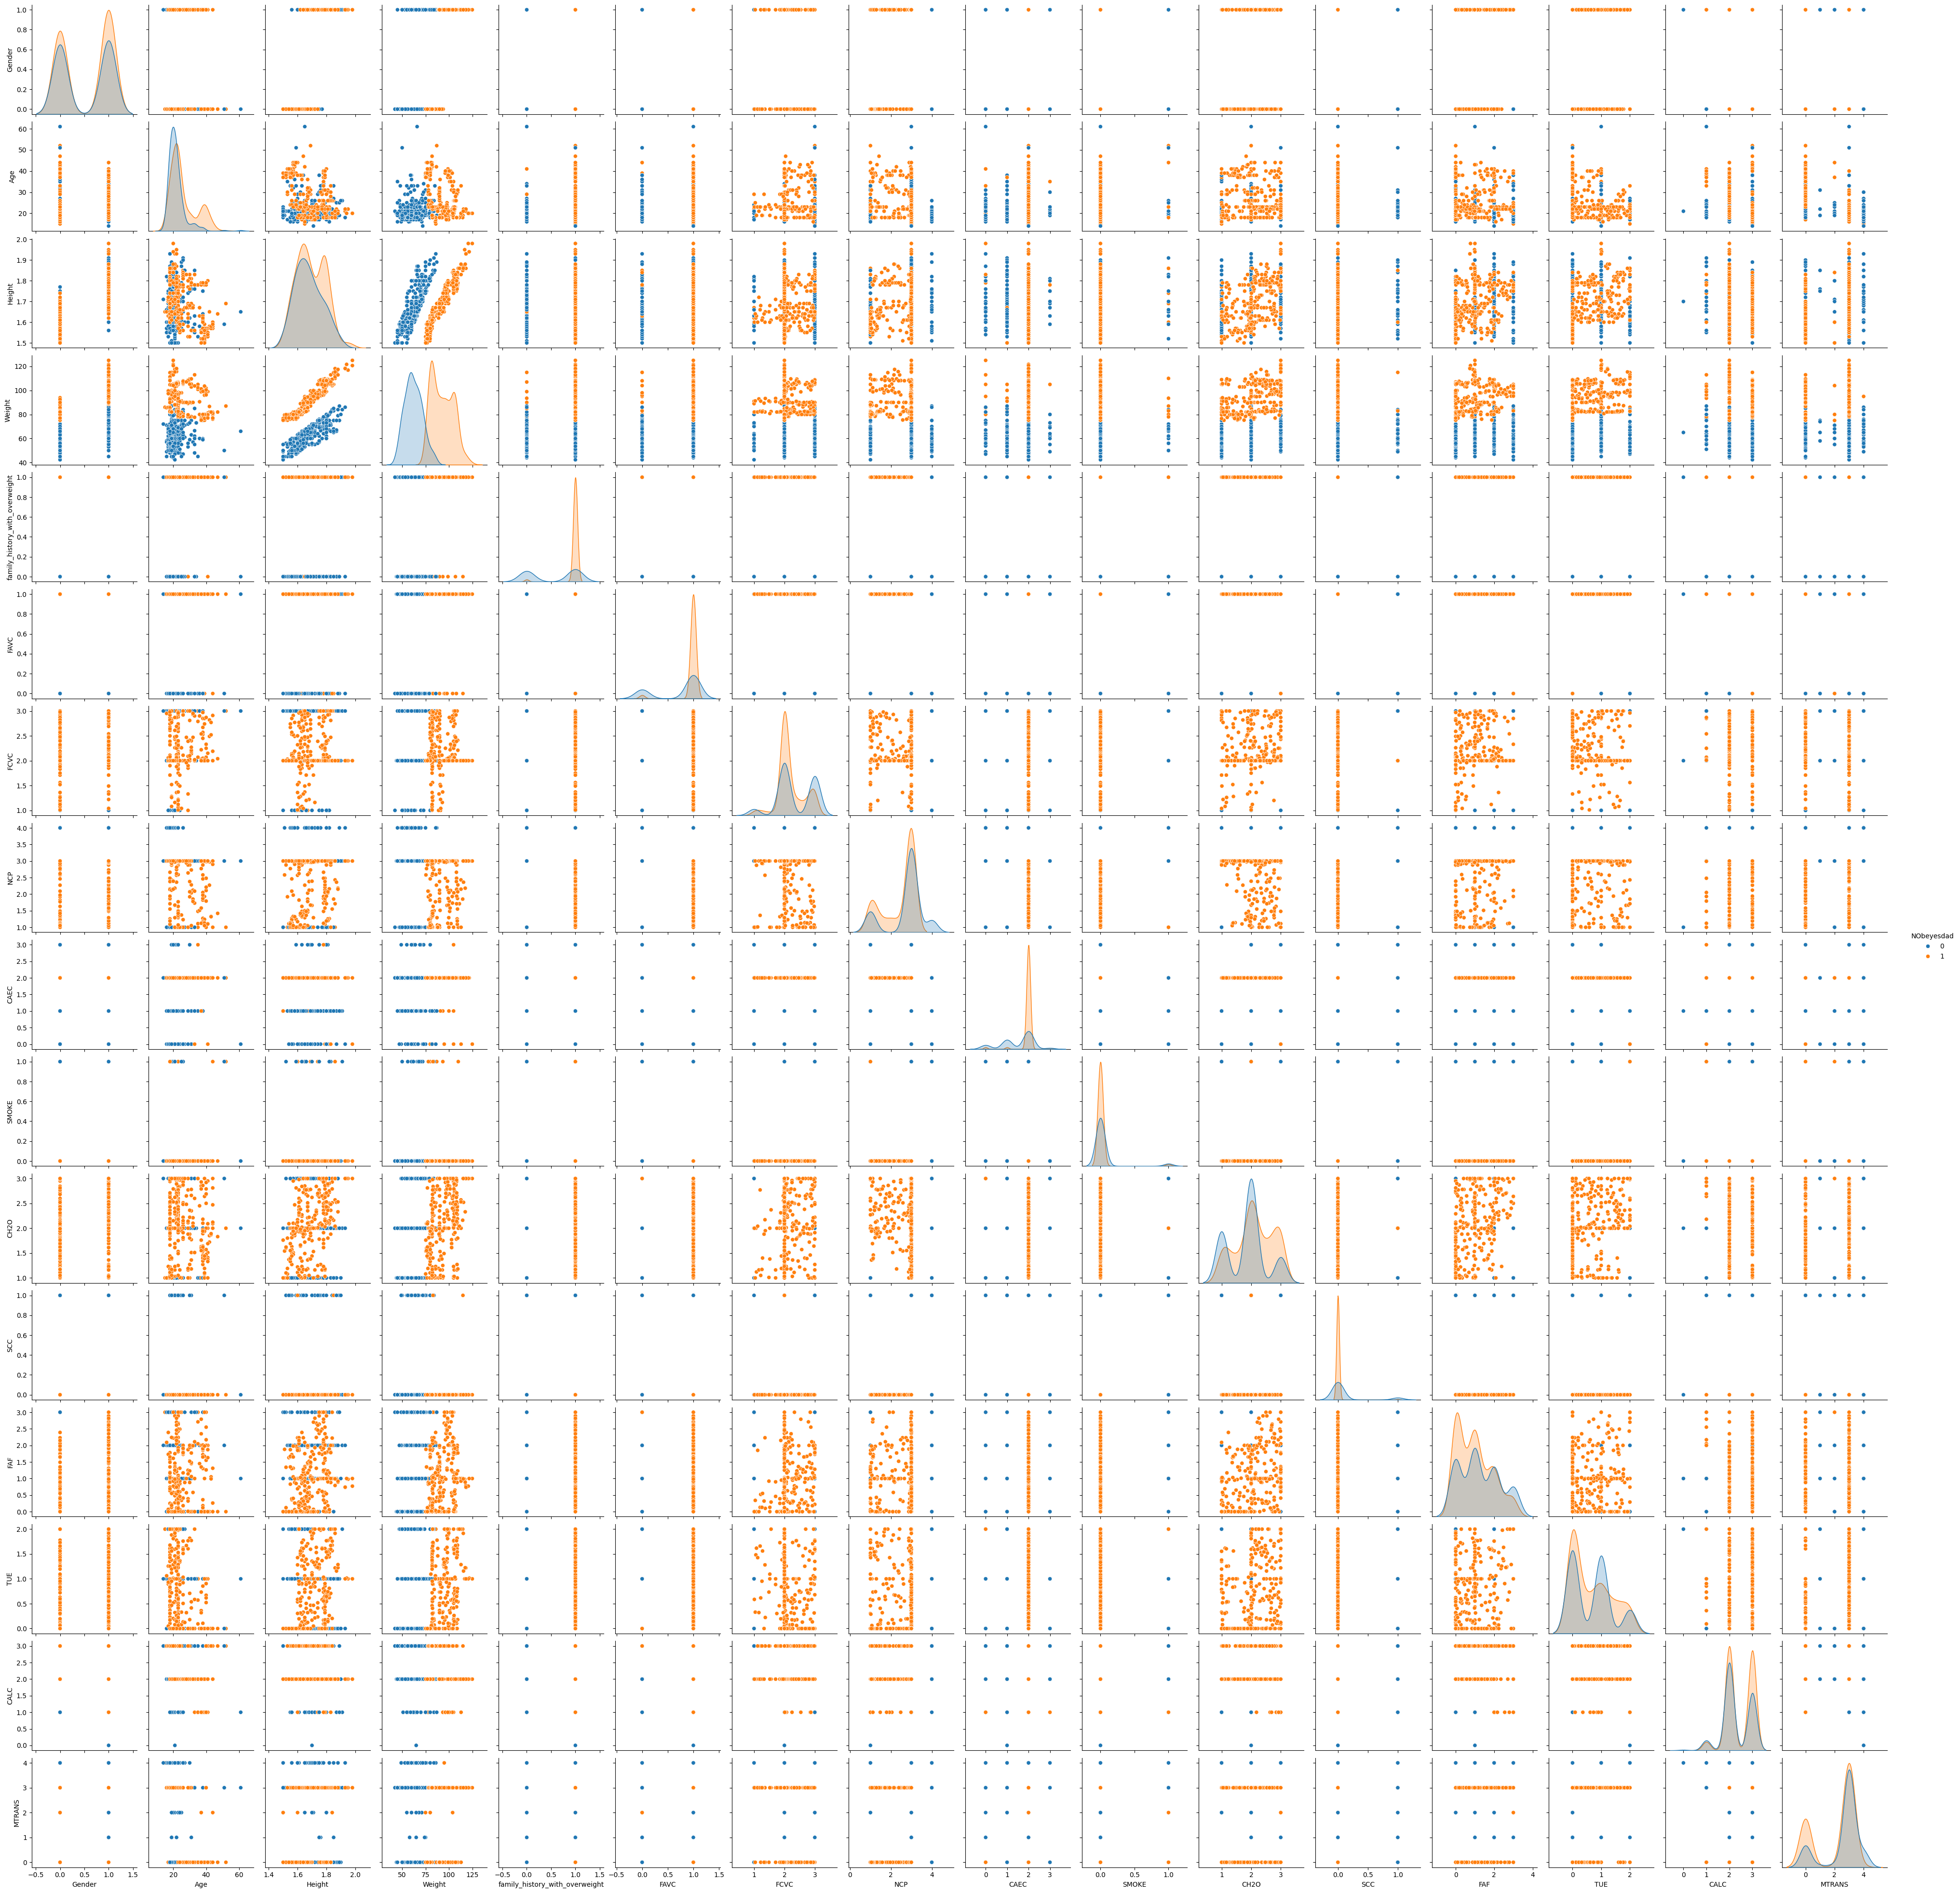

In [ ]:
sns.pairplot(df_binary, hue='NObeyesdad')

Confusion Matrix

In [ ]:
def plot_confusion_matrix(cm, title):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Positive', 'Negative'])
    fig, ax = plt.subplots(figsize=(10, 8))
    disp.plot(ax=ax, colorbar=True, cmap='Blues')
    labels = ['TP', 'FP', 'FN', 'TN']
    counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
    positions = [(0, 0), (1, 0), (0, 1), (1, 1)]
    colors = ['white', 'black', 'black', 'white']
    for label, count, pos, color in zip(labels, counts, positions, colors):
        x, y = pos
        offset_x = 0.05 if 'FP' in label else -0.05
        offset_y = -0.1 if 'FN' in label else 0.1
        ax.text(x + offset_x, y + offset_y, f"{label} = {count}", ha='center', va='center', color=color, fontsize=12, fontweight='bold')
    plt.title(title)
    plt.show()

# **Define features and target variables**

In [ ]:
# define features and target variables (X and y)
X = df_binary.drop('NObeyesdad', axis=1)
y = df_binary['NObeyesdad']

In [ ]:
print(y.value_counts())

NObeyesdad
1    351
0    282
Name: count, dtype: int64


# **Train Test Split**

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# split the data into training data and test data (X represents data, Y represents label)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, stratify=y, random_state=42)

print(X.shape, X_train.shape, X_test.shape)

(633, 16) (474, 16) (159, 16)


# **Logistic Regression**

**Training the Model**

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
start_time = time.time()

In [ ]:
lr.fit(X_train, y_train)

LogisticRegression()

**Timing the Training Process**

In [ ]:
lr_training_time = time.time() - start_time
print("Logistic Regression Training time: {:.2f} seconds".format(lr_training_time))
start_time = time.time()

Logistic Regression Training time: 0.07 seconds


**Model Evaluation**

In [ ]:
y_test_prediction_lr = lr.predict(X_test)

**Timing the Testing Process**

In [ ]:
lr_testing_time = time.time() - start_time
print("Logistic Regression Testing time: {:.2f} seconds".format(lr_testing_time))

Logistic Regression Testing time: 0.02 seconds


**Accuracy Score on the Training Data**

In [ ]:
y_train_prediction_lr = lr.predict(X_train)
lr_training_data_accuracy = accuracy_score(y_train, y_train_prediction_lr)
print('Logistic Regression Training Data Accuracy: {:.2%}'.format(lr_training_data_accuracy))

Logistic Regression Training Data Accuracy: 99.16%


**Accuracy Score on the Testing Data**

In [ ]:
lr_test_data_accuracy = accuracy_score(y_test, y_test_prediction_lr)
print('Logistic Regression Test Data Accuracy: {:.2%}'.format(lr_test_data_accuracy))

Logistic Regression Test Data Accuracy: 97.48%


**Confusion Matrix:Logistic Regression**

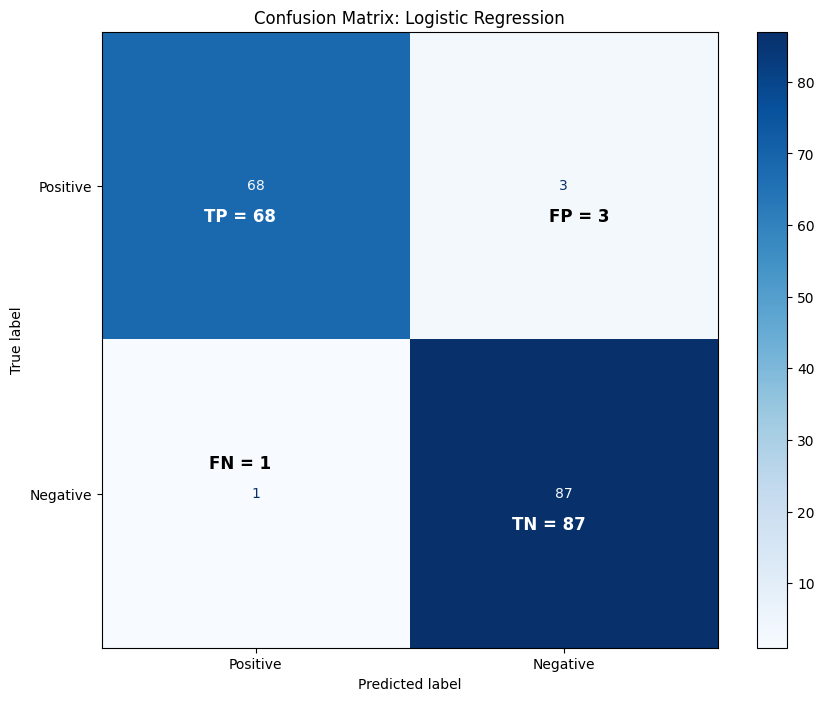

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97        71
           1       0.97      0.99      0.98        88

    accuracy                           0.97       159
   macro avg       0.98      0.97      0.97       159
weighted avg       0.98      0.97      0.97       159



In [ ]:
cm_lr = confusion_matrix(y_test, y_test_prediction_lr)
plot_confusion_matrix(cm_lr, "Confusion Matrix: Logistic Regression")

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_test_prediction_lr))

**Cross Validation: Logistic Regression**

In [ ]:
# Define parameter grid
param_grid_lr = { 'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l2'], 'solver': ['liblinear'] }

# Grid search with 5-fold cross-validation
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), param_grid_lr, cv=5)
grid_lr.fit(X_train, y_train)

# Best estimator
best_lr_model = grid_lr.best_estimator_
print("Best Logistic Regression Params:", grid_lr.best_params_)

# Predict using best model
y_test_prediction_lr = best_lr_model.predict(X_test)

Best Logistic Regression Params: {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}


# **Support Vector Machine (SVM)**

**Training the Model**

In [ ]:
from sklearn.svm import SVC

svms = SVC(probability=True, kernel='rbf')
start_time = time.time()

In [ ]:
svms.fit(X_train, y_train)

SVC(probability=True)

**Timing the Training Process**

In [ ]:
svm_training_time = time.time() - start_time
print("SVM Training time: {:.2f} seconds".format(svm_training_time))

SVM Training time: 0.04 seconds


**Model Evaluation**

In [ ]:
y_test_prediction_svm = svms.predict(X_test)

**Timing the Testing Process**

In [ ]:
svm_testing_time = time.time() - start_time
print("SVM Testing time: {:.2f} seconds".format(svm_testing_time))

SVM Testing time: 0.06 seconds


**Accuracy Score on the Training Data**

In [ ]:
y_train_prediction_svm = svms.predict(X_train)
svm_training_data_accuracy = accuracy_score(y_train, y_train_prediction_svm)
print('SVM Training Data Accuracy: {:.2%}'.format(svm_training_data_accuracy))

SVM Training Data Accuracy: 95.78%


**Accuracy Score on the Testing Data**

In [ ]:
svm_test_data_accuracy = accuracy_score(y_test, y_test_prediction_svm)
print('SVM Test Data Accuracy: {:.2%}'.format(svm_test_data_accuracy))

SVM Test Data Accuracy: 96.86%


**Confusion Matrix: Support Vector Machine (SVM)**

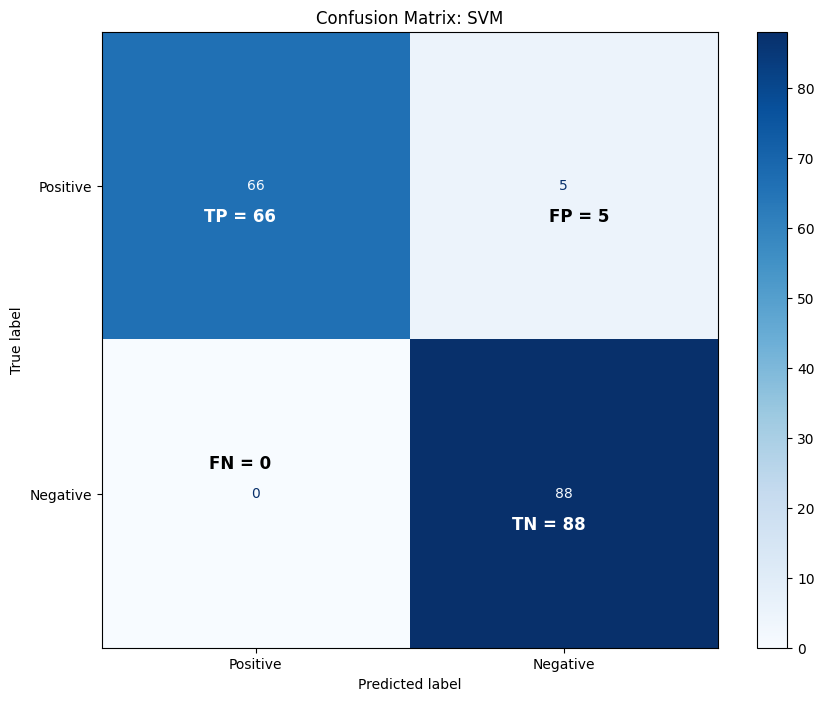

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        71
           1       0.95      1.00      0.97        88

    accuracy                           0.97       159
   macro avg       0.97      0.96      0.97       159
weighted avg       0.97      0.97      0.97       159



In [ ]:
cm_svm = confusion_matrix(y_test, y_test_prediction_svm)
plot_confusion_matrix(cm_svm, "Confusion Matrix: SVM")

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_test_prediction_svm))

**Cross Validation: Support Vector Machine (SVM)**

In [ ]:
# Define parameter grid
param_grid_svm = {  'C': [0.1, 1, 10], 'kernel': ['rbf'], 'gamma': ['scale', 0.01, 0.001] }

# Grid search with 5-fold cross-validation
grid_svm = GridSearchCV(SVC(probability=True), param_grid_svm, cv=5)
grid_svm.fit(X_train, y_train)

# Best estimator
best_svm_model = grid_svm.best_estimator_
print("Best SVM Params:", grid_svm.best_params_)

# Predict using best model
y_test_prediction_svm = best_svm_model.predict(X_test)

Best SVM Params: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}


# **K-Nearest Neighbors (KNN)**

**Training the Model**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knns = KNeighborsClassifier(n_neighbors=5)
start_time = time.time()

In [ ]:
knns.fit(X_train, y_train)

KNeighborsClassifier()

**Timing the Training Process**

In [ ]:
knn_training_time = time.time() - start_time
print("KNN Training time: {:.4f} seconds".format(knn_training_time))
start_time = time.time()

KNN Training time: 0.0229 seconds


**Model Evaluation**

In [ ]:
y_test_prediction_knn = knns.predict(X_test)

**Timing the Testing Process**

In [ ]:
knn_testing_time = time.time() - start_time
print("KNN Testing time: {:.2f} seconds".format(knn_testing_time))

KNN Testing time: 0.03 seconds


**Accuracy Score on the Training Data**

In [ ]:
y_train_prediction_knn = knns.predict(X_train)
knn_training_data_accuracy = accuracy_score(y_train, y_train_prediction_knn)
print('KNN Training Data Accuracy: {:.2%}'.format(knn_training_data_accuracy))

KNN Training Data Accuracy: 97.26%


**Accuracy Score on the Testing Data**

In [ ]:
knn_test_data_accuracy = accuracy_score(y_test, y_test_prediction_knn)
print('KNN Test Data Accuracy: {:.2%}'.format(knn_test_data_accuracy))

KNN Test Data Accuracy: 97.48%


**Confusion Matrix: K-Nearest Neighbors (KNN)**

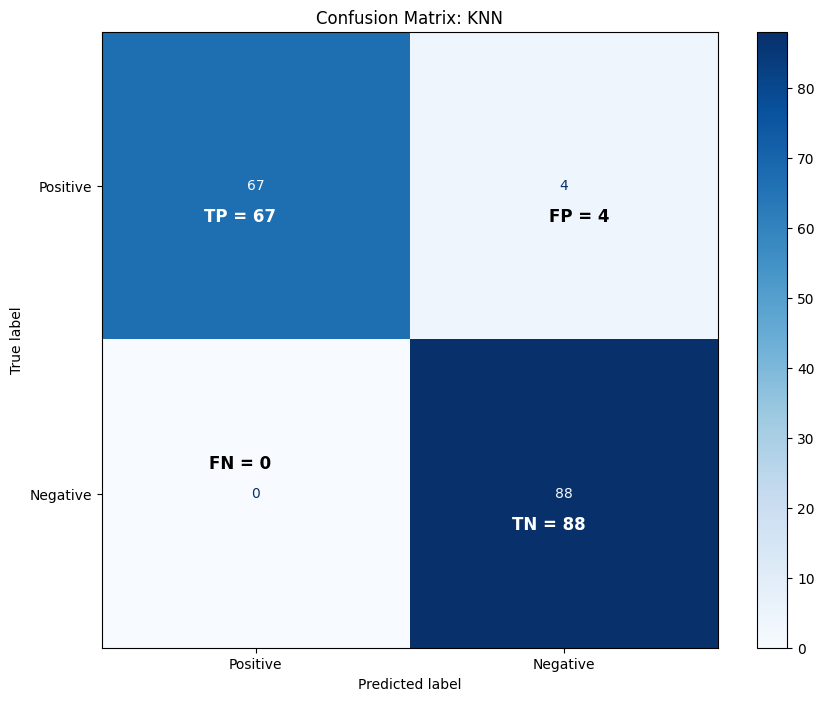

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        71
           1       0.96      1.00      0.98        88

    accuracy                           0.97       159
   macro avg       0.98      0.97      0.97       159
weighted avg       0.98      0.97      0.97       159



In [ ]:
cm_knn = confusion_matrix(y_test, y_test_prediction_knn)
plot_confusion_matrix(cm_knn, "Confusion Matrix: KNN")

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_test_prediction_knn))

**Cross Validation: K-Nearest Neighbors (KNN)**

In [ ]:
# Define parameter grid
param_grid_knn = {  'n_neighbors': [3, 5, 7, 9, 11] }

# Grid search with 5-fold cross-validation
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5)
grid_knn.fit(X_train, y_train)

# Best estimator
best_knn_model = grid_knn.best_estimator_
print("Best KNN Params:", grid_knn.best_params_)

# Predict using best model
y_test_prediction_knn = best_knn_model.predict(X_test)

Best KNN Params: {'n_neighbors': 3}


# **ROC (Receiver Operating Characteristic) curves**

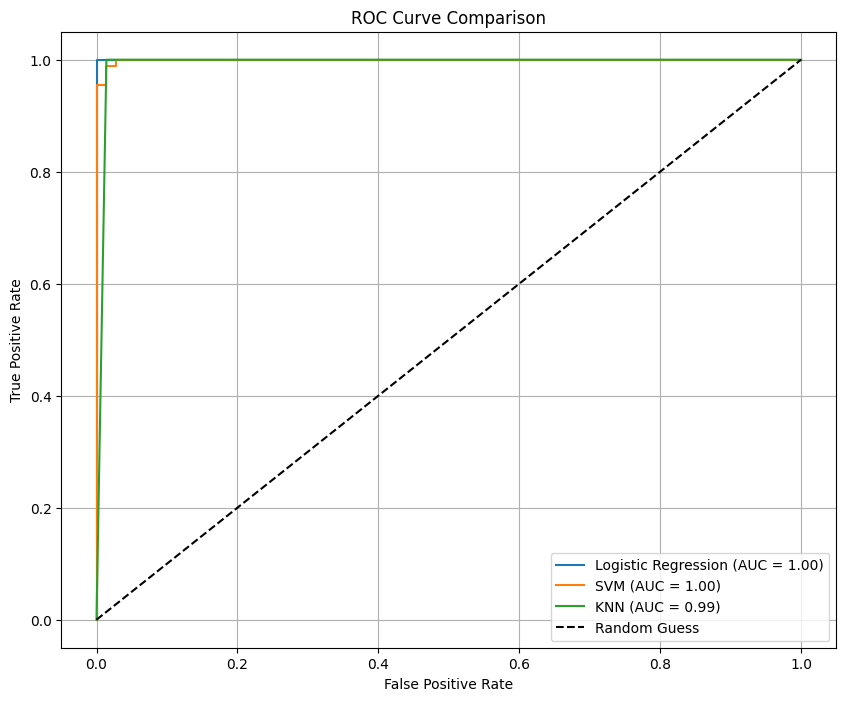

In [ ]:
# Logistic Regression
y_score_lr = best_lr_model.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_score_lr)
auc_log = auc(fpr_lr, tpr_lr)

# SVM
y_score_svm = best_svm_model.decision_function(X_test)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_score_svm)
auc_svm = auc(fpr_svm, tpr_svm)

# KNN
y_score_knn = best_knn_model.predict_proba(X_test)[:, 1]
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_score_knn)
auc_knn = auc(fpr_knn, tpr_knn)

# Plot all ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_log:.2f})')
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.2f})')
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# Labels and legend
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# **Compare the Classifiers**

Model Performance Comparison:
                 Model  Training Time (s)  Testing Time (s)  \
0  Logistic Regression           0.068624          0.015452   
1                  SVM           0.039433          0.063999   
2                  KNN           0.022879          0.028109   

   Training Accuracy (%)  Testing Accuracy (%)     AUC (%)  
0              99.156118            100.000000  100.000000  
1              95.780591             98.742138   99.919974  
2              97.257384             97.484277   99.295775  




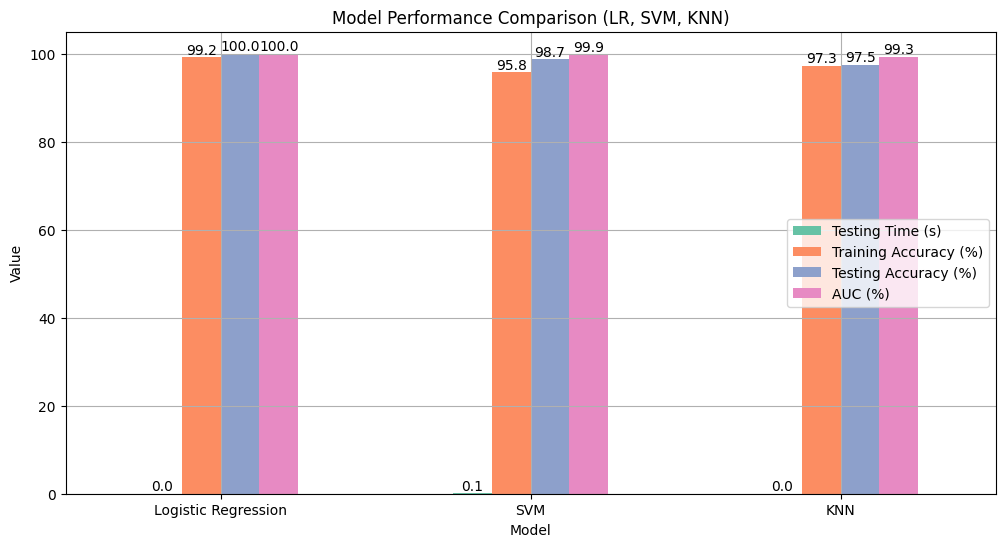

In [ ]:
# Define metrics for comparison
metrics = {
    'Model': ['Logistic Regression', 'SVM', 'KNN'],
    'Training Time (s)': [lr_training_time, svm_training_time, knn_training_time],
    'Testing Time (s)': [lr_testing_time, svm_testing_time, knn_testing_time],
    'Training Accuracy (%)': [lr_training_data_accuracy * 100, svm_training_data_accuracy * 100, knn_training_data_accuracy * 100],
    'Testing Accuracy (%)': [accuracy_score(y_test, y_test_prediction_lr) * 100,
                              accuracy_score(y_test, y_test_prediction_svm) * 100,
                              accuracy_score(y_test, y_test_prediction_knn) * 100],
    'AUC (%)': [auc_log * 100, auc_svm * 100, auc_knn * 100]
}

# Create DataFrame
comparison_df = pd.DataFrame(metrics)

# Display the DataFrame
print("Model Performance Comparison:")
print(comparison_df)
print()
print()
# Bar chart visualization
ax = comparison_df.set_index('Model').iloc[:, 1:].plot(
    kind='bar',
    figsize=(12, 6),
    color=sns.color_palette("Set2")
)
plt.title('Model Performance Comparison (LR, SVM, KNN)')
plt.ylabel('Value')
plt.xticks(rotation=0)
plt.grid(True)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=10)

plt.show()


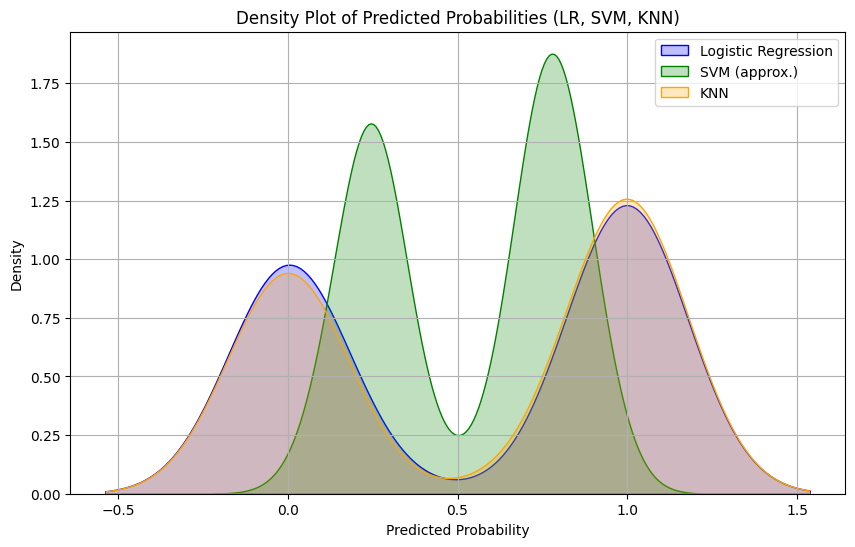

In [ ]:
# Get predicted probabilities or decision scores

# Logistic Regression
lr_probs = best_lr_model.predict_proba(X_test)[:, 1]

# SVM - decision_function scores to probabilities (approximate)
svm_scores = best_svm_model.decision_function(X_test)
svm_probs = 1 / (1 + np.exp(-svm_scores))

# KNN
knn_probs = best_knn_model.predict_proba(X_test)[:, 1]

# Plot density curves
plt.figure(figsize=(10, 6))
sns.kdeplot(lr_probs, label='Logistic Regression', shade=True, color='blue')
sns.kdeplot(svm_probs, label='SVM (approx.)', shade=True, color='green')
sns.kdeplot(knn_probs, label='KNN', shade=True, color='orange')
plt.title('Density Plot of Predicted Probabilities (LR, SVM, KNN)')
plt.xlabel('Predicted Probability')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()
